# EfficientNet-B0 dos etapas (head-only + fine-tuning parcial)

Este notebook entrena EfficientNet-B0 en dos fases:
1. Entrena solo el clasificador final (head-only).
2. Descongela parcialmente capas altas para fine-tuning con LR menor.

Estructura esperada: data/train, data/valid, data/test

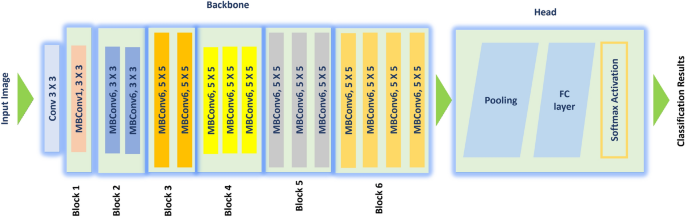

In [10]:
import random
import time
import copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, f1_score

plt.style.use('seaborn-v0_8')

In [11]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

Dispositivo: cpu


In [12]:
DATA_DIR = Path("Dog's skin diseases-Kaggle_v_corta")
assert DATA_DIR.exists(), f'No se encontro la carpeta: {DATA_DIR.resolve()}'

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

datasets_map = {
    'train': datasets.ImageFolder(DATA_DIR / 'train', transform=train_tfms),
    'valid': datasets.ImageFolder(DATA_DIR / 'valid', transform=eval_tfms),
    'test': datasets.ImageFolder(DATA_DIR / 'test', transform=eval_tfms),
}

dataloaders = {
    split: DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=(split == 'train'),
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == 'cuda')
    )
    for split, ds in datasets_map.items()
}

class_names = datasets_map['train'].classes
num_classes = len(class_names)

print('Clases:', class_names)
print('Tamano train/valid/test:', len(datasets_map['train']), len(datasets_map['valid']), len(datasets_map['test']))

Clases: ['Demodicosis', 'Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'Ringworm']
Tamano train/valid/test: 1258 370 183


In [13]:
targets = np.array(datasets_map['train'].targets)
class_counts = np.bincount(targets, minlength=num_classes)
class_weights = class_counts.sum() / (num_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

for i, c in enumerate(class_names):
    print(f'{c}: n={class_counts[i]}, weight={class_weights[i].item():.4f}')

Demodicosis: n=210, weight=0.9984
Dermatitis: n=210, weight=0.9984
Fungal_infections: n=210, weight=0.9984
Healthy: n=204, weight=1.0278
Hypersensitivity: n=210, weight=0.9984
Ringworm: n=214, weight=0.9798


In [14]:
def build_efficientnet_b0(num_classes):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

#def build_Resnet_18(num_classes):
    weights = models.resnet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def freeze_backbone(model):
    for p in model.features.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True


def unfreeze_top_blocks(model, n_blocks=3):
    # Congela todo backbone primero
    for p in model.features.parameters():
        p.requires_grad = False

    # Descongela ultimos bloques de features
    children = list(model.features.children())
    for block in children[-n_blocks:]:
        for p in block.parameters():
            p.requires_grad = True

    # Clasificador siempre entrenable
    for p in model.classifier.parameters():
        p.requires_grad = True


model = build_efficientnet_b0(num_classes).to(device)
freeze_backbone(model)
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [18]:
def freeze_backbone2(model):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.fc.parameters():
        p.requires_grad = True
def build_Resnet50(num_classes):
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model3 = build_Resnet50(num_classes).to(device)
freeze_backbone2(model3)
model3

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [16]:
def trainable_params_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Parametros entrenables actuales:', trainable_params_count(model))

Parametros entrenables actuales: 7686


In [17]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    running_loss, running_correct, n_samples = 0.0, 0, 0
    all_preds, all_targets = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        preds = logits.argmax(dim=1)
        bs = labels.size(0)

        running_loss += loss.item() * bs
        running_correct += (preds == labels).sum().item()
        n_samples += bs

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(labels.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / n_samples
    epoch_acc = running_correct / n_samples
    epoch_f1 = f1_score(all_targets, all_preds, average='macro')
    return epoch_loss, epoch_acc, epoch_f1


def train_with_early_stopping(model, train_loader, valid_loader, criterion, optimizer, scheduler, epochs=10, patience=4, phase_name='phase'):
    best_state = copy.deepcopy(model.state_dict())
    best_valid_f1 = -1.0
    best_epoch = -1
    wait = 0

    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'valid_loss': [], 'valid_acc': [], 'valid_f1': [],
        'lr': []
    }

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        valid_loss, valid_acc, valid_f1 = run_epoch(model, valid_loader, criterion, optimizer=None)

        scheduler.step(valid_f1)
        lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['valid_loss'].append(valid_loss)
        history['valid_acc'].append(valid_acc)
        history['valid_f1'].append(valid_f1)
        history['lr'].append(lr)

        print(
            f'[{phase_name}] Epoch {epoch:02d}/{epochs} | '
            f'train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | '
            f'valid loss {valid_loss:.4f} acc {valid_acc:.4f} f1 {valid_f1:.4f} | '
            f'lr {lr:.2e}'
        )

        if valid_f1 > best_valid_f1:
            best_valid_f1 = valid_f1
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f'[{phase_name}] Early stopping en epoch {epoch}.')
            break

    elapsed = (time.time() - t0) / 60
    model.load_state_dict(best_state)

    print(f'[{phase_name}] Mejor epoch: {best_epoch} | Mejor valid macro-F1: {best_valid_f1:.4f} | Tiempo: {elapsed:.2f} min')
    return model, history, best_valid_f1

In [18]:
# Etapa 1: head-only
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer_stage1 = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-4,
    weight_decay=1e-4
)
scheduler_stage1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage1, mode='max', factor=0.5, patience=2, min_lr=1e-6
)

model, hist_stage1, best_f1_stage1 = train_with_early_stopping(
    model=model,
    train_loader=dataloaders['train'],
    valid_loader=dataloaders['valid'],
    criterion=criterion,
    optimizer=optimizer_stage1,
    scheduler=scheduler_stage1,
    epochs=8,
    patience=3,
    phase_name='stage1-head'
)

[stage1-head] Epoch 01/8 | train loss 1.6151 acc 0.4173 f1 0.4139 | valid loss 1.4099 acc 0.6000 f1 0.5807 | lr 5.00e-04
[stage1-head] Epoch 02/8 | train loss 1.2841 acc 0.6630 f1 0.6572 | valid loss 1.1870 acc 0.6838 f1 0.6634 | lr 5.00e-04
[stage1-head] Epoch 03/8 | train loss 1.1119 acc 0.7067 f1 0.7028 | valid loss 1.0873 acc 0.7000 f1 0.6854 | lr 5.00e-04
[stage1-head] Epoch 04/8 | train loss 1.0198 acc 0.7377 f1 0.7333 | valid loss 1.0190 acc 0.7189 f1 0.7049 | lr 5.00e-04
[stage1-head] Epoch 05/8 | train loss 0.9545 acc 0.7464 f1 0.7445 | valid loss 0.9715 acc 0.7216 f1 0.7133 | lr 5.00e-04
[stage1-head] Epoch 06/8 | train loss 0.9264 acc 0.7576 f1 0.7551 | valid loss 0.9332 acc 0.7432 f1 0.7314 | lr 5.00e-04
[stage1-head] Epoch 07/8 | train loss 0.8841 acc 0.7663 f1 0.7651 | valid loss 0.9009 acc 0.7541 f1 0.7485 | lr 5.00e-04
[stage1-head] Epoch 08/8 | train loss 0.8526 acc 0.7750 f1 0.7734 | valid loss 0.8668 acc 0.7568 f1 0.7469 | lr 5.00e-04
[stage1-head] Mejor epoch: 7 | M

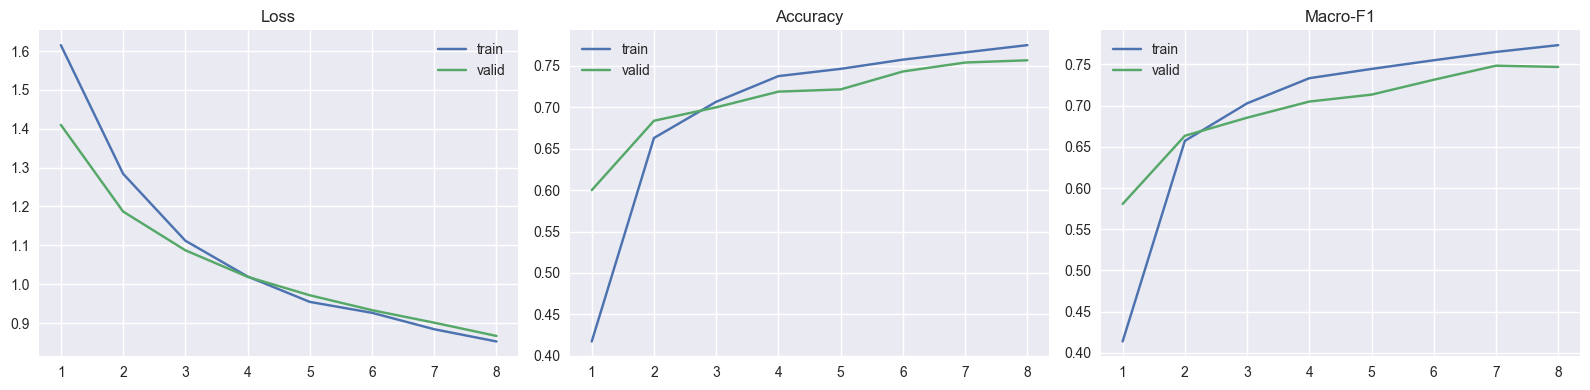

In [21]:
plot_history(hist_stage1)

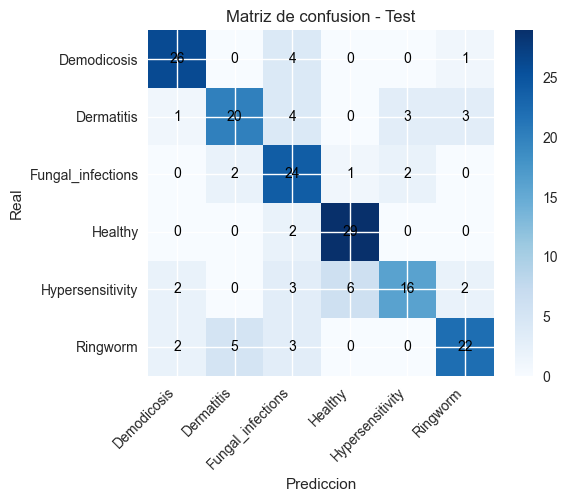

In [22]:
cm = confusion_matrix(test_targets, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusion - Test')

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [23]:
#model_resnet50_mod
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer_stage1 = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-4,
    weight_decay=1e-4
)
scheduler_stage1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage1, mode='max', factor=0.5, patience=2, min_lr=1e-6
)

model_resnet50_mod, hist_stage2, best_f1_stage2 = train_with_early_stopping(
    model=model3,
    train_loader=dataloaders['train'],
    valid_loader=dataloaders['valid'],
    criterion=criterion,
    optimizer=optimizer_stage1,
    scheduler=scheduler_stage1,
    epochs=8,
    patience=3,
    phase_name='stage1-head'
)

[stage1-head] Epoch 01/8 | train loss 1.8003 acc 0.1471 f1 0.1274 | valid loss 1.7941 acc 0.1622 f1 0.1468 | lr 5.00e-04
[stage1-head] Epoch 02/8 | train loss 1.8030 acc 0.1447 f1 0.1261 | valid loss 1.7951 acc 0.1541 f1 0.1349 | lr 5.00e-04
[stage1-head] Epoch 03/8 | train loss 1.8015 acc 0.1351 f1 0.1156 | valid loss 1.7952 acc 0.1568 f1 0.1376 | lr 5.00e-04
[stage1-head] Epoch 04/8 | train loss 1.7998 acc 0.1463 f1 0.1299 | valid loss 1.7954 acc 0.1622 f1 0.1470 | lr 5.00e-04
[stage1-head] Epoch 05/8 | train loss 1.8006 acc 0.1399 f1 0.1187 | valid loss 1.7964 acc 0.1541 f1 0.1375 | lr 5.00e-04
[stage1-head] Epoch 06/8 | train loss 1.8019 acc 0.1614 f1 0.1387 | valid loss 1.7944 acc 0.1541 f1 0.1343 | lr 5.00e-04
[stage1-head] Epoch 07/8 | train loss 1.7992 acc 0.1471 f1 0.1307 | valid loss 1.7940 acc 0.1568 f1 0.1346 | lr 2.50e-04
[stage1-head] Early stopping en epoch 7.
[stage1-head] Mejor epoch: 4 | Mejor valid macro-F1: 0.1470 | Tiempo: 36.54 min


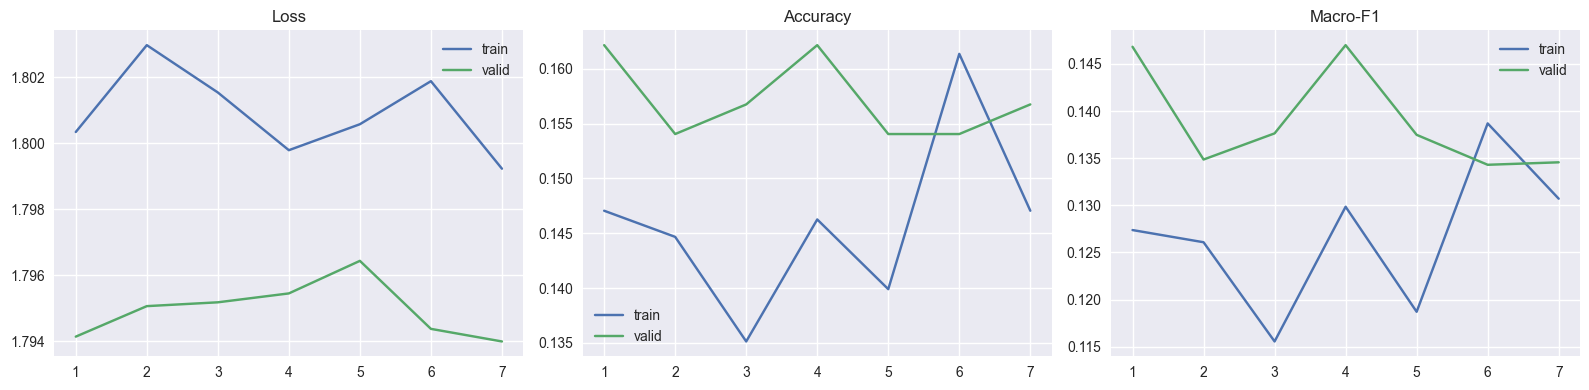

In [28]:
plot_history(hist_stage2)

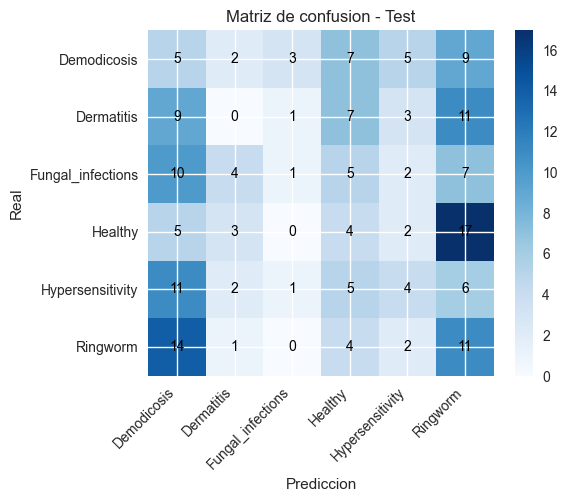

In [30]:
cm = confusion_matrix(test_targets_resnet, test_preds_resnet)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusion - Test')

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [24]:
def build_mobilenet_v3(num_classes):
    weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    model = models.mobilenet_v3_small(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model

model_mobilnet = build_efficientnet_b0(num_classes).to(device)
freeze_backbone(model_mobilnet)
model_mobilnet

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [25]:
#mobilenet_v3
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer_stage1 = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-4,
    weight_decay=1e-4
)
scheduler_stage1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage1, mode='max', factor=0.5, patience=2, min_lr=1e-6
)

model_mobilnet, hist_mobilnet, best_f1_mobilnet = train_with_early_stopping(
    model=model_mobilnet,
    train_loader=dataloaders['train'],
    valid_loader=dataloaders['valid'],
    criterion=criterion,
    optimizer=optimizer_stage1,
    scheduler=scheduler_stage1,
    epochs=8,
    patience=3,
    phase_name='stage1-head'
)

[stage1-head] Epoch 01/8 | train loss 1.8147 acc 0.1781 f1 0.1540 | valid loss 1.7888 acc 0.2000 f1 0.1834 | lr 5.00e-04
[stage1-head] Epoch 02/8 | train loss 1.8218 acc 0.1622 f1 0.1407 | valid loss 1.7922 acc 0.1919 f1 0.1677 | lr 5.00e-04
[stage1-head] Epoch 03/8 | train loss 1.8194 acc 0.1725 f1 0.1462 | valid loss 1.7894 acc 0.2081 f1 0.1863 | lr 5.00e-04
[stage1-head] Epoch 04/8 | train loss 1.8201 acc 0.1622 f1 0.1395 | valid loss 1.7885 acc 0.1946 f1 0.1721 | lr 5.00e-04
[stage1-head] Epoch 05/8 | train loss 1.8190 acc 0.1638 f1 0.1326 | valid loss 1.7859 acc 0.1892 f1 0.1652 | lr 5.00e-04
[stage1-head] Epoch 06/8 | train loss 1.8189 acc 0.1614 f1 0.1344 | valid loss 1.7865 acc 0.1892 f1 0.1691 | lr 2.50e-04
[stage1-head] Early stopping en epoch 6.
[stage1-head] Mejor epoch: 3 | Mejor valid macro-F1: 0.1863 | Tiempo: 10.93 min


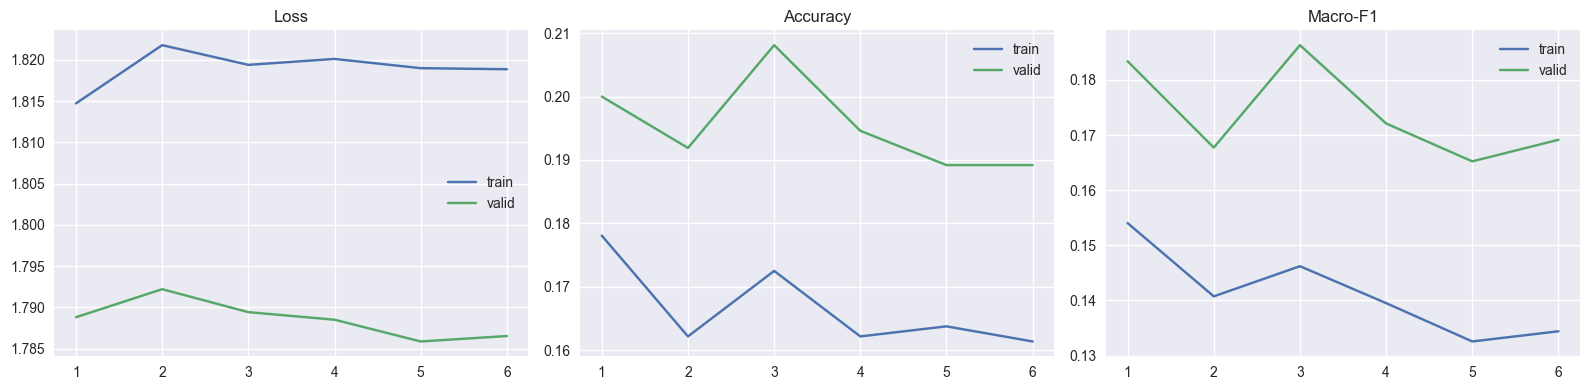

In [27]:
plot_history(hist_mobilnet)

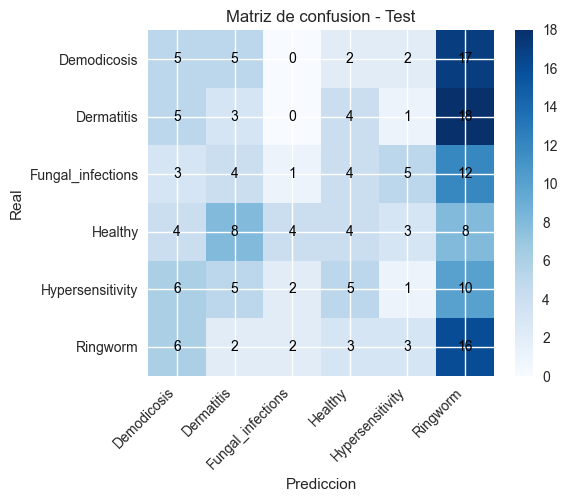

In [31]:
cm = confusion_matrix(test_targets_mobil, test_preds_mobil)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusion - Test')

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [85]:
# Etapa 2: fine-tuning parcial
unfreeze_top_blocks(model, n_blocks=3)
print('Parametros entrenables en stage 2:', trainable_params_count(model))

optimizer_stage2 = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4,
    weight_decay=1e-4
)
scheduler_stage2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2, mode='max', factor=0.5, patience=2, min_lr=1e-6
)

model, hist_stage2, best_f1_stage2 = train_with_early_stopping(
    model=model,
    train_loader=dataloaders['train'],
    valid_loader=dataloaders['valid'],
    criterion=criterion,
    optimizer=optimizer_stage2,
    scheduler=scheduler_stage2,
    epochs=25,
    patience=3,
    phase_name='stage2-finetune'
)

Parametros entrenables en stage 2: 3163426
[stage2-finetune] Epoch 01/25 | train loss 0.8173 acc 0.7957 f1 0.7943 | valid loss 0.7528 acc 0.8054 f1 0.7986 | lr 1.00e-04
[stage2-finetune] Epoch 02/25 | train loss 0.6436 acc 0.8537 f1 0.8532 | valid loss 0.6621 acc 0.8432 f1 0.8367 | lr 1.00e-04
[stage2-finetune] Epoch 03/25 | train loss 0.5344 acc 0.9062 f1 0.9059 | valid loss 0.5913 acc 0.8649 f1 0.8609 | lr 1.00e-04
[stage2-finetune] Epoch 04/25 | train loss 0.4723 acc 0.9285 f1 0.9285 | valid loss 0.5562 acc 0.8838 f1 0.8820 | lr 1.00e-04
[stage2-finetune] Epoch 05/25 | train loss 0.4330 acc 0.9459 f1 0.9459 | valid loss 0.5214 acc 0.9000 f1 0.8977 | lr 1.00e-04
[stage2-finetune] Epoch 06/25 | train loss 0.3981 acc 0.9626 f1 0.9626 | valid loss 0.5080 acc 0.8973 f1 0.8958 | lr 1.00e-04
[stage2-finetune] Epoch 07/25 | train loss 0.3696 acc 0.9690 f1 0.9692 | valid loss 0.4890 acc 0.9081 f1 0.9073 | lr 1.00e-04
[stage2-finetune] Epoch 08/25 | train loss 0.3456 acc 0.9809 f1 0.9810 | va

In [19]:
hist_stage1["train_loss"]


[1.6151076181893886,
 1.2841382066471967,
 1.1119387684262614,
 1.019821481030014,
 0.9544505135812138,
 0.9263715315699009,
 0.8841030205376387,
 0.8526356733849773]

In [86]:
def merge_histories(h1, h2):
    out = {}
    for k in h1.keys():
        out[k] = h1[k] + h2[k]
    return out

history = merge_histories(hist_stage1, hist_stage2)

print(f'Best valid macro-F1 stage1: {best_f1_stage1:.4f}')
print(f'Best valid macro-F1 stage2: {best_f1_stage2:.4f}')

Best valid macro-F1 stage1: 0.7184
Best valid macro-F1 stage2: 0.9184


In [19]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['valid_loss'], label='valid')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='train')
    axes[1].plot(epochs, history['valid_acc'], label='valid')
    axes[1].set_title('Accuracy')
    axes[1].legend()

    axes[2].plot(epochs, history['train_f1'], label='train')
    axes[2].plot(epochs, history['valid_f1'], label='valid')
    axes[2].set_title('Macro-F1')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

#plot_history(hist_stage1)

In [20]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds, targets = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        pred = logits.argmax(dim=1).cpu().numpy()
        preds.extend(pred.tolist())
        targets.extend(labels.numpy().tolist())
    return np.array(preds), np.array(targets)

test_preds, test_targets = predict_loader(model, dataloaders['test'])
#test_preds_resnet, test_targets_resnet = predict_loader(model_resnet50_mod, dataloaders['test'])
#test_preds_mobil, test_targets_mobil = predict_loader(model_mobilnet, dataloaders['test'])
test_acc = (test_preds == test_targets).mean()
test_f1 = f1_score(test_targets, test_preds, average='macro')

print(f'Test accuracy: {test_acc:.4f}')
print(f'Test macro-F1: {test_f1:.4f}')
print('\nClassification report (test):')
print(classification_report(test_targets, test_preds, target_names=class_names))

Test accuracy: 0.7486
Test macro-F1: 0.7438

Classification report (test):
                   precision    recall  f1-score   support

      Demodicosis       0.84      0.84      0.84        31
       Dermatitis       0.74      0.65      0.69        31
Fungal_infections       0.60      0.83      0.70        29
          Healthy       0.81      0.94      0.87        31
 Hypersensitivity       0.76      0.55      0.64        29
         Ringworm       0.79      0.69      0.73        32

         accuracy                           0.75       183
        macro avg       0.76      0.75      0.74       183
     weighted avg       0.76      0.75      0.75       183



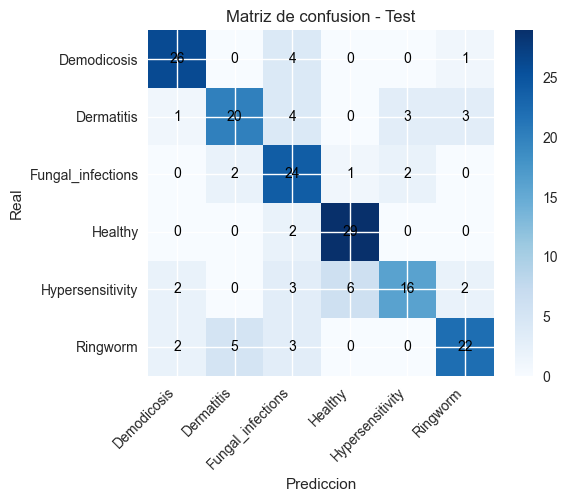

In [22]:
cm = confusion_matrix(test_targets, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusion - Test')

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [23]:
out_dir = Path('models')
out_dir.mkdir(parents=True, exist_ok=True)

model_path = out_dir / 'dog_skin_efficientnet_b0_two_stage_merged_best.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'img_size': IMG_SIZE
}, model_path)

print('Modelo guardado en:', model_path.resolve())

Modelo guardado en: C:\Users\richi\OneDrive\Desktop\Proyectos\Repositorio-Prueba\models\dog_skin_efficientnet_b0_two_stage_merged_best.pt


In [3]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
import os
from io import BytesIO
import shutil
from pathlib import Path
import random as rnd
from glob import glob

In [6]:
# Librerías de explicabilidad (Grad-CAM)
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [16]:
from pathlib import Path

def find_weights_path() -> Path:
    """Busca los pesos de ResNet18 en ubicaciones comunes del proyecto."""
    candidates = [
        Path("models\dog_skin_efficientnet_b0_two_stage_merged_best.pth"),
        Path("./dog_skin_efficientnet_b0_two_stage_merged_best.pth"),
        Path("../dog_skin_efficientnet_b0_two_stage_merged_best.pth"),
        Path.cwd() / "dog_skin_efficientnet_b0_two_stage_merged_best.pth",
        Path.cwd().parent / "dog_skin_efficientnet_b0_two_stage_merged_best.pth",
        #Path("../resnet18_rocole_final.pth"),
        #Path("./resnet18_rocole_final.pth"),
        #Path.cwd() / "resnet18_rocole_final.pth",
        #Path.cwd().parent / "resnet18_rocole_final.pth",
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError(
        "No se encontró resnet18_rocole_final.pth. Debe estar en la raíz del proyecto."
    )

def build_input_from_pil(pil_img: Image.Image):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    rgb_img = np.array(pil_img.resize((224, 224)), dtype=np.float32) / 255.0
    input_tensor = transform(pil_img).unsqueeze(0)
    return rgb_img, input_tensor

def build_leaf_mask_and_crop(
    pil_img: Image.Image,
    pad_ratio: float = 0.08,
    bg_color=(128, 128, 128),
):
    """Genera máscara de hoja, recorte con padding y recorte enmascarado con fondo neutro."""
    img_rgb = np.array(pil_img)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Rango amplio para verdes y amarillos de hoja
    lower = np.array([20, 20, 20], dtype=np.uint8)
    upper = np.array([95, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)

    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        h, w = mask.shape
        fallback_mask = np.ones((h, w), dtype=np.uint8) * 255
        return fallback_mask, pil_img, pil_img, (0, 0, w, h)

    cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)

    # Más padding para conservar contexto útil cercano a la hoja
    pad = int(pad_ratio * max(w, h))
    x0 = max(0, x - pad)
    y0 = max(0, y - pad)
    x1 = min(mask.shape[1], x + w + pad)
    y1 = min(mask.shape[0], y + h + pad)

    crop_rgb = img_rgb[y0:y1, x0:x1]
    crop_mask = mask[y0:y1, x0:x1]

    # Fondo neutro para reducir sesgo de contexto
    bg = np.full_like(crop_rgb, bg_color, dtype=np.uint8)
    crop_masked = crop_rgb.copy()
    crop_masked[crop_mask == 0] = bg[crop_mask == 0]

    pil_crop = Image.fromarray(crop_rgb)
    pil_crop_masked = Image.fromarray(crop_masked)
    return mask, pil_crop, pil_crop_masked, (x0, y0, x1 - x0, y1 - y0)

<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\richi\AppData\Local\Temp\ipykernel_9112\3443316005.py:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  Path("models\dog_skin_efficientnet_b0_two_stage_merged_best.pth"),
